In [1]:
import sys
sys.path.append("..")

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from services.utils_data import read_and_transform_data

/home/victor_muryn/ConEfuV2/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SUM_12_PATH = "../datasets_pre_defined/sum_12_fixed.jsonlines"
SUM_14_PATH = "../datasets_pre_defined/sum_14_final.jsonlines"
UNIQUE_SENTENCES_PATH = './raw_sentences/unique_lemma_sentences.jsonl'

## SUM 12

In [3]:
data_sum_12 = read_and_transform_data(SUM_12_PATH, homonym=True)

# sort by Ukrainian alphabet
alph = "АаБбВвГгҐґДдЕеЄєЖжЗзИиІіЇїЙйКкЛлМмНнОоПпРрСсТтУуФфХхЦцЧчШшЩщьЮюЯя"
data_sum_12 = data_sum_12.sort_values(by='lemma', key=lambda x: x.str.translate(str.maketrans({c: f"{i:02}" for i, c in enumerate(alph)})))
data_sum_12

,lemma,gloss,examples
0,абака,"[Чотирикутна плита, якою завершується верхня ч...",[Абака – плоска плита у верхній частині капіте...
1,абака,[Пальмоподібна багаторічна тропічна рослина ро...,[Кращий у світі канат – манільський – робиться...
2,аверс,"[Лицевий бік монети, медалі, медальйона ]",[На аверсі монети на фоні півкуль Землі зображ...
3,аверс,"[Прямий напрямок руху; використання механізму,...","[– Ви знаєте, що практично з часу введення в е..."
6,авізо,[Офіційне повідомлення про виконання розрахунк...,"[Особливо широко термін ""авізо"" застосовується..."
...,...,...,...
2436,підзол,"[Неродючий, бідний на поживні речовини ґрунт б...","[Підзоли розвиваються там, де протягом тривало..."
2437,підзол,"[Суміш попелу з вапном, яку використовують для...","[З будь-якого компонента, що містить вапно (ка..."
2439,підкачати,"[Підгортаючи, піднімаючи краї, робити коротшим...",[Нараз він схватився зі свого місця і почав як...
2440,підкачати,"[Не виконати яких-небудь зобов'язань, не випра...","[– Ну, тепер ти, Максиме, наш! Перед всім наро..."


In [4]:
# unique lemmas
data_sum_12.lemma.nunique()

1135

count    2375.000000
mean        5.307789
std         7.031102
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        81.000000
dtype: float64


<Axes: >

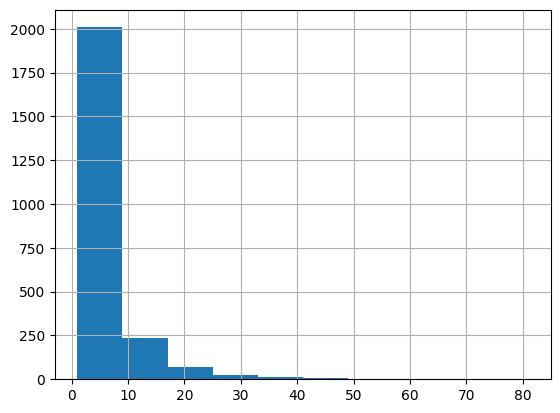

In [5]:
n_examples_per_lemma = data_sum_12.apply(lambda x: len(x["examples"]), axis=1)
print(n_examples_per_lemma.describe())
n_examples_per_lemma.hist()

## SUM 14

In [6]:
data_sum_14 = read_and_transform_data(SUM_14_PATH, homonym=True)

# sort by Ukrainian alphabet
alph = "АаБбВвГгҐґДдЕеЄєЖжЗзИиІіЇїЙйКкЛлМмНнОоПпРрСсТтУуФфХхЦцЧчШшЩщьЮюЯя"
data_sum_14 = data_sum_14.sort_values(by='lemma', key=lambda x: x.str.translate(str.maketrans({c: f"{i:02}" for i, c in enumerate(alph)})))
data_sum_14

,lemma,gloss,examples
0,абака,"[Чотирикутна плита, якою завершується верхня ч...",[Абака – плоска плита у верхній частині капіте...
1,абака,[Пальмоподібна багаторічна тропічна рослина ро...,[Кращий у світі канат – манільський – робиться...
2,аверс,"[Лицевий бік монети, медалі, медальйона ]",[На аверсі монети на фоні півкуль Землі зображ...
3,аверс,"[Прямий напрямок руху; використання механізму,...","[– Ви знаєте, що практично з часу введення в е..."
6,авізо,[Офіційне повідомлення про виконання розрахунк...,"[Особливо широко термін ""авізо"" застосовується..."
...,...,...,...
3006,празелень,[Синювато-зелена фарба чи колір],"[В старім порту солоний вітер віє, Повзе по му..."
3009,прас,[Прес],"[Оце в мене сир під прасом, Має мій милий близ..."
3008,прас,[Праска],"[Нагрівся прас. Прасувала, клала до складочки ..."
3011,прасувати,"[Надмірно або жадібно їсти, споживати, Сильно ...","[– Таких панів, що бублик у руці держить, а чо..."


we have up to letter П

In [7]:
# unique lemmas
data_sum_14.lemma.nunique()

1434

count    3007.000000
mean        5.259395
std         7.204726
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        81.000000
dtype: float64
Median number of examples per lemma in SUM-14: 3.0


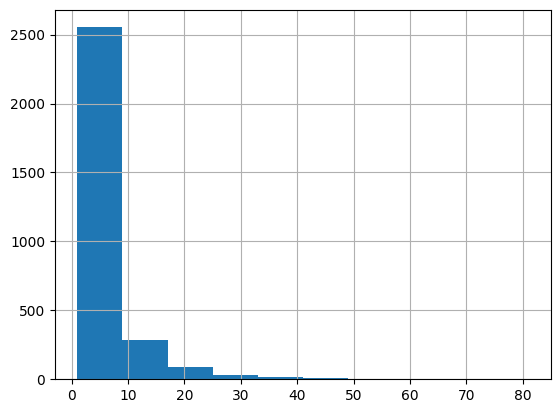

In [8]:
n_examples_per_lemma = data_sum_14.apply(lambda x: len(x["examples"]), axis=1)
print(n_examples_per_lemma.describe())
n_examples_per_lemma.hist()

# show median
print("Median number of examples per lemma in SUM-14:", n_examples_per_lemma.median())

In [9]:
# Total examples
total_examples = n_examples_per_lemma.sum()
print("Total number of examples in SUM-14:", total_examples)

Total number of examples in SUM-14: 15815


In [10]:
# select lemma мати
lemma_maty = data_sum_14[data_sum_14['lemma'] == 'лютий']
print(lemma_maty['examples'].values[1][5])

Почулася різка команда, лютий гавкіт собак


In [11]:
print(*data_sum_14.lemma.unique(), sep="\n")

абака
аверс
авізо
автостоп
аерон
ажур
айсинг
акліматизатор
аколада
акорд
актив
актор
акція
амброзія
американка
аніс
антифон
апорт
аргонавт
аргус
аркан
арнаутка
артикул
аспід
атлас
бабувати
багатоніжка
байка
балабан
баланс
балда
балка
балувати
бальбоа
баляси
бамбула
бандо
банк
банка
банкет
банник
баранта
барда
басма
батарея
батьківщина
безвікий
безгрішний
безділля
бездільний
безпровідний
безрозмірний
бергамот
бережина
береза
берест
берестянка
билина
било
бирка
бистрянка
биток
бичувати
бігма
бігунок
біда
білиця
білозір
білок
біль
біндер
близня
блок
блуд
блудити
бовтанка
бокс
боксер
болгарка
болівар
болід
бони
босоніжка
бостон
бочка
брак
бракувати
брас
бродити
бронювати
броня
брякнути
бубон
бугай
буда
будь-що
буза
буквиця
бунт
бурбон
бурити
бурка
бурса
бутин
бутність
бухта
буцім
бушель
вайда
валити
валковий
валовий
вальок
вара
варт
варунок
вахта
венгерка
венет
веприна
вергун
веред
верещака
верея
вернути
верства
вертун
верхогляд
веснянка
весь
вибігати
виброджувати
вибучувати
вивергати
виві

## UberText 2.0

In [12]:
with open(UNIQUE_SENTENCES_PATH, 'r') as f:
    data_ubertext = [json.loads(line) for line in f]

In [13]:
lemmas = set([item['lemma'] for item in data_ubertext])
len(lemmas)

1362

In [14]:
lemmas_without_sentences = set(data_sum_14['lemma'].unique()) - lemmas
len(lemmas_without_sentences)

96

In [15]:
# find вара in data_sum_14
data_sum_14[data_sum_14['lemma'] == 'вара']

,lemma,gloss,examples
251,вара,[Геть],"[Вара, вара з-під віконця, хлопче, Чи ласка па..."
252,вара,[Міра довжини в багатьох країнах Латинської Ам...,[Величина вари – від 80 до 110 см]


In [16]:
lemmas_without_sentences

{'безвікий',
 'вибучувати',
 'волохи',
 'візирування',
 'візирувати',
 'віолан',
 'віолент',
 'віридин',
 'вітритися',
 'десцендент',
 'докувати',
 'дометати',
 'допаювати',
 'дотопити',
 'дрібушки',
 'емітувальний',
 'заляскотати',
 'зашліхтовувати',
 'кондиціонал',
 'ланцювати',
 'лесотка',
 'лесувати',
 'мелопластика',
 'миколайчики',
 'надвозити',
 'назолити',
 'накупати',
 'накушувати',
 'налигнути',
 'налініювати',
 'намулитися',
 'настьобати',
 'нутряк',
 'обезкрилити',
 'обповзати',
 'оброчник',
 'одвір',
 'палильник',
 'перекалатати',
 'перекантовувати',
 'перелініювати',
 'переметати',
 "переп'ясти",
 'перепарувати',
 'пересмикати',
 'перестьобати',
 'перетіпати',
 'по-словенському',
 'повиглядати',
 'повириватися',
 'повиходжувати',
 'повмазувати',
 'повшивати',
 'погикати',
 'позавиватися',
 'позаголювати',
 'позамулюватися',
 'позамішувати',
 'позапливати',
 'позапускатися',
 'позасікати',
 'позатаскувати',
 'позаточувати',
 'позаїжджати',
 'позворушувати',
 'позлигувати',

count    1.362000e+03
mean     8.815098e+03
std      5.674140e+04
min      1.000000e+00
25%      2.400000e+01
50%      2.175000e+02
75%      1.536000e+03
max      1.309977e+06
dtype: float64


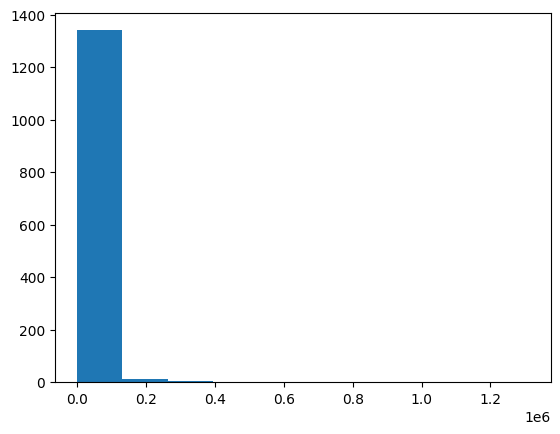

In [17]:
sentences_per_lemma = pd.Series([len(item['sentences']) for item in data_ubertext])
print(sentences_per_lemma.describe())

plt.hist(sentences_per_lemma);

In [18]:
# find where len(sentences) > 1000
long_lemmas = [item for item in data_ubertext if len(item['sentences']) > 1000]
# sort by len(sentences)
long_lemmas = sorted(long_lemmas, key=lambda x: len(x['sentences']), reverse=True)
len(long_lemmas)

417

In [19]:
total_sentences = sum([len(item['sentences']) for item in data_ubertext])
top_20_sentences = sum([len(item['sentences']) for item in long_lemmas[:20]])
print(f"Total sentences in long lemmas: {total_sentences:,}")
print(f"Top 20 lemmas cover {top_20_sentences:,} sentences, which is {top_20_sentences / total_sentences:.2%} of all sentences.")

print()
for item in long_lemmas[:20]:
    print(f"{item['lemma']:<13}: {len(item['sentences']):,} sentences")

Total sentences in long lemmas: 12,006,163
Top 20 lemmas cover 6,862,605 sentences, which is 57.16% of all sentences.

мати         : 1,309,977 sentences
весь         : 1,030,147 sentences
місто        : 703,032 sentences
зараз        : 436,165 sentences
кілька       : 344,082 sentences
держава      : 334,304 sentences
початок      : 311,643 sentences
передавати   : 274,936 sentences
перебувати   : 243,282 sentences
лютий        : 223,693 sentences
відповідний  : 183,573 sentences
акція        : 178,009 sentences
планувати    : 175,110 sentences
година       : 172,663 sentences
план         : 167,193 sentences
банк         : 166,375 sentences
око          : 158,542 sentences
директор     : 151,806 sentences
орган        : 149,650 sentences
зона         : 148,423 sentences


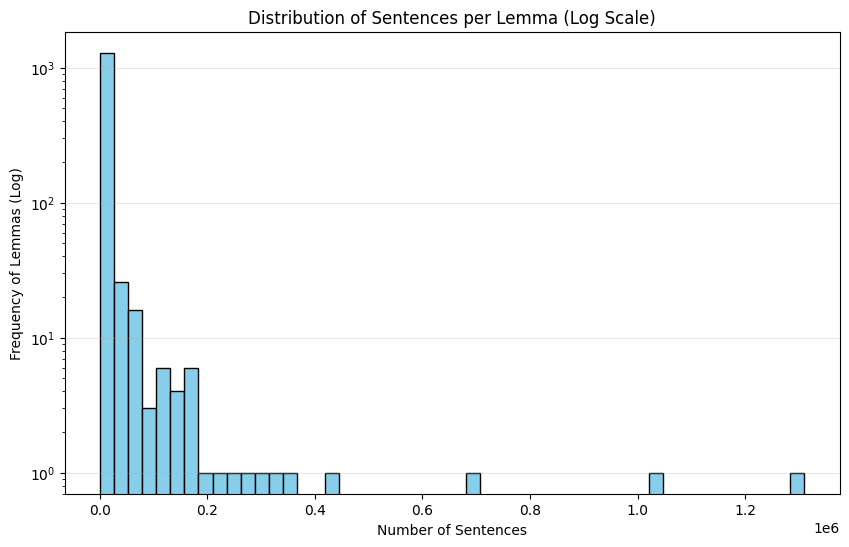

In [34]:
# Prep the data
counts = [len(item['sentences']) for item in data_ubertext]

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=50, log=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentences per Lemma (Log Scale)')
plt.xlabel('Number of Sentences')
plt.ylabel('Frequency of Lemmas (Log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

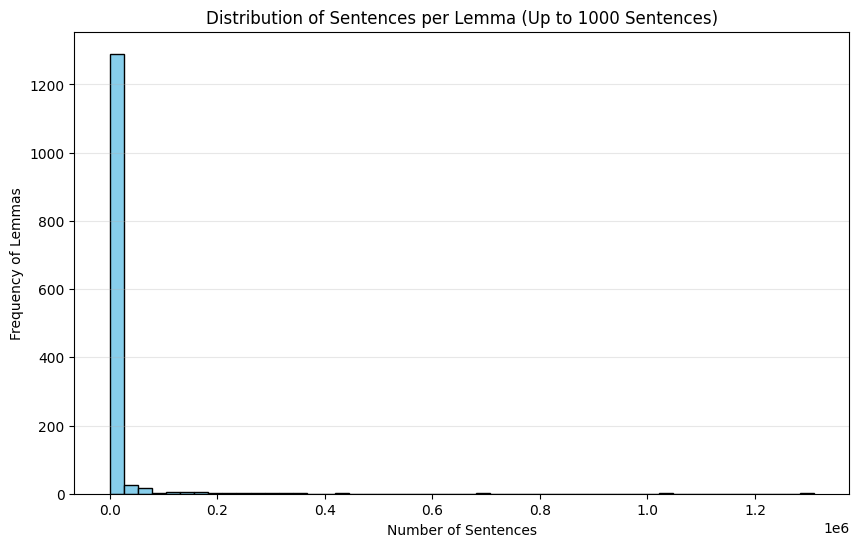

In [21]:
# Prep the data
counts = [len(item['sentences']) for item in data_ubertext]

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentences per Lemma (Up to 1000 Sentences)')
plt.xlabel('Number of Sentences')
plt.ylabel('Frequency of Lemmas')
plt.grid(axis='y', alpha=0.3)
plt.show()

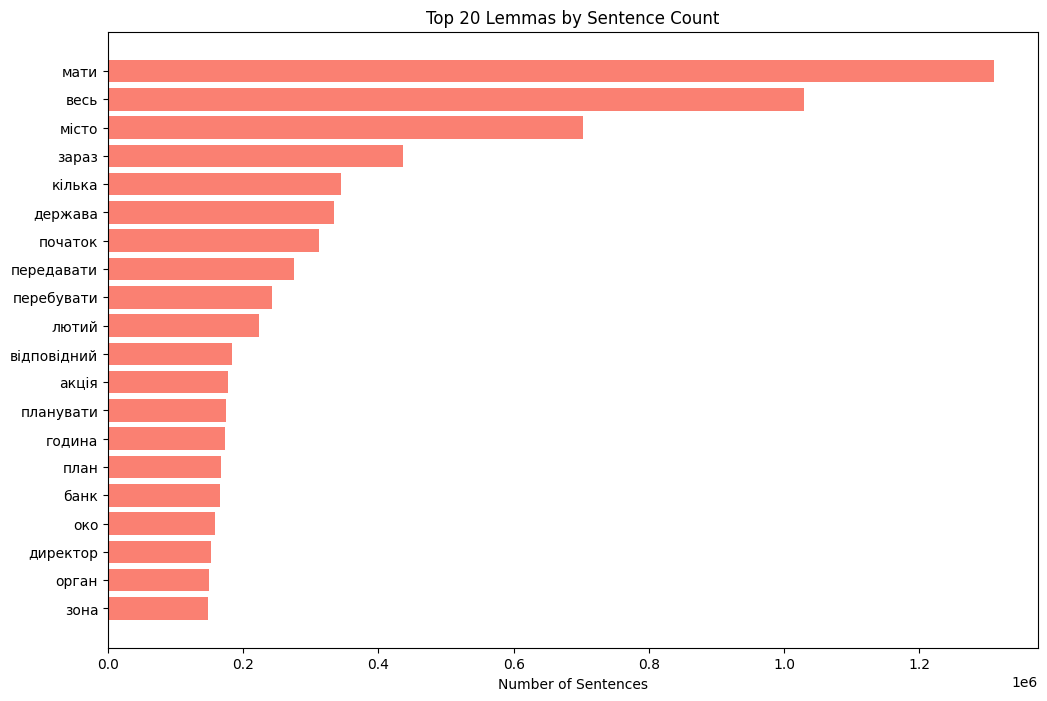

In [22]:
# Sort and grab top 20
top_lemmas = sorted(data_ubertext, key=lambda x: len(x['sentences']), reverse=True)[:20]
labels = [item['lemma'] for item in top_lemmas]
values = [len(item['sentences']) for item in top_lemmas]

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='salmon')
plt.title('Top 20 Lemmas by Sentence Count')
plt.xlabel('Number of Sentences')
plt.show()

In [ ]:
df_counts = pd.Series(counts)
# disable scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(df_counts.describe(percentiles=[.25, .5, .75, .9, .95, .99]))

Median 217.5
count      1362.00
mean       8815.10
std       56741.40
min           1.00
25%          24.00
50%         217.50
75%        1536.00
90%        9795.10
95%       28655.55
99%      169326.30
max     1309977.00
dtype: float64


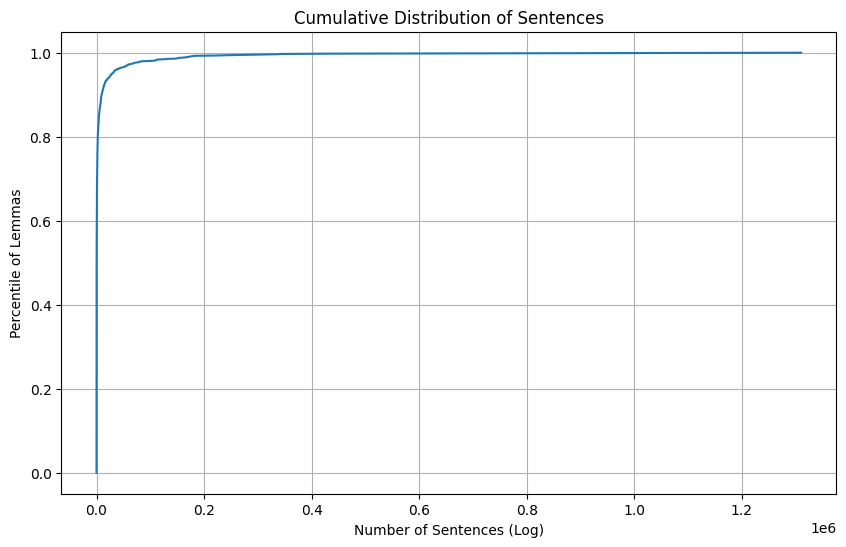

In [24]:
sorted_counts = np.sort(counts)
p = np.arange(len(sorted_counts)) / float(len(sorted_counts) - 1)

plt.figure(figsize=(10, 6))
plt.plot(sorted_counts, p)
# plt.xscale('log') # Crucial because of your 10k outliers
plt.title('Cumulative Distribution of Sentences')
plt.xlabel('Number of Sentences (Log)')
plt.ylabel('Percentile of Lemmas')
plt.grid(True)
plt.show()

In [25]:
sum(min(len(item['sentences']), 100) for item in data_ubertext)

94823

In [32]:
sum(1 if len(item['sentences']) < 1 else 0 for item in data_ubertext)

0